<a href="https://colab.research.google.com/github/qorwlghks/26-BDA/blob/main/titanic_improved.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 타이타닉 생존/사망 분석

이 노트북은 타이타닉 탑승자 데이터를 이용해 생존에 영향을 미친 요인들을 분석합니다.

**분석 목차**
1. 데이터 로드 및 전처리
2. 기본 생존 통계 분석
3. 객실 등급 및 갑판(Deck)별 분석
4. 인적 구성 및 동반자 여부 분석
5. 수치형 데이터 분포 분석
6. 시각화
7. 분석 결과 요약

### 1. 데이터 로드 및 전처리

In [1]:
# ── 패키지 및 폰트 설치 (Google Colab 환경) ──────────────────────────
import subprocess, importlib

# 나눔 폰트 설치
subprocess.run(['apt-get', 'install', '-y', '-q', 'fonts-nanum'], capture_output=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
%matplotlib inline

# 폰트 캐시 초기화 후 나눔 폰트 등록
fm._load_fontmanager(try_read_cache=False)
nanum_fonts = [f for f in fm.findSystemFonts() if 'Nanum' in f]
font_prop = None
if nanum_fonts:
    font_prop = fm.FontProperties(fname=nanum_fonts[0])
    font_name = fm.FontProperties(fname=nanum_fonts[0]).get_name()
    plt.rc('font', family=font_name)
    print(f'폰트 설정 완료: {font_name}')
else:
    print('나눔 폰트를 찾을 수 없습니다. 기본 폰트를 사용합니다.')
plt.rcParams['axes.unicode_minus'] = False

# ── 데이터 다운로드 ───────────────────────────────────────────────────
import os, urllib.request

DATA_URL = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
DATA_PATH = 'titanic.csv'

if not os.path.exists(DATA_PATH):
    print('데이터 다운로드 중...')
    urllib.request.urlretrieve(DATA_URL, DATA_PATH)
    print('다운로드 완료!')

df = pd.read_csv(DATA_PATH)

# 원본 데이터 컬럼 확인 후 Fare 없으면 0으로 채움
if 'Fare' not in df.columns:
    df['Fare'] = 0

print(f'원본 데이터 크기: {df.shape[0]}명 x {df.shape[1]}개 컬럼')
print('\n[컬럼별 결측치 개수]')
print(df[['Survived', 'Pclass', 'Sex', 'Age', 'Embarked', 'SibSp', 'Parch', 'Cabin', 'Fare']].isnull().sum())

폰트 설정 완료: NanumMyeongjo
데이터 다운로드 중...
다운로드 완료!
원본 데이터 크기: 891명 x 12개 컬럼

[컬럼별 결측치 개수]
Survived      0
Pclass        0
Sex           0
Age         177
Embarked      2
SibSp         0
Parch         0
Cabin       687
Fare          0
dtype: int64


In [2]:
# 분석에 사용할 컬럼 선택
selected_columns = ['Survived', 'Pclass', 'Sex', 'Age', 'Embarked', 'SibSp', 'Parch', 'Cabin', 'Fare']
data = df[selected_columns].copy()

# -------------------------------------------------------
# 결측치 처리 전략
#   Age    : 중앙값으로 대체 (77%가 아닌 20% 수준의 결측 → 보존 가치 있음)
#   Embarked: 최빈값(S)으로 대체 (결측 2건, 거의 없음)
#   Cabin  : 결측 = 'Unknown'으로 처리 후 첫 글자(Deck)만 추출
#            → dropna() 사용 시 1014건(77%) 삭제되어 분석 신뢰도 크게 저하됨
# -------------------------------------------------------

age_median = data['Age'].median()
data['Age'] = data['Age'].fillna(age_median)
data['Embarked'] = data['Embarked'].fillna(data['Embarked'].mode()[0])

# Cabin: 첫 글자를 Deck으로 추출, 없으면 'Unknown'
data['Deck'] = data['Cabin'].apply(lambda x: x[0] if pd.notna(x) else 'Unknown')

# Fare 결측 처리 (거의 없음)
data['Fare'] = data['Fare'].fillna(data['Fare'].median())

# Survived 레이블 변환 (0 → Dead, 1 → Survived)
data['Survived'] = data['Survived'].map({0: 'Dead', 1: 'Survived'})

# 파생 변수 생성
data['adult_male'] = ((data['Sex'] == 'male') & (data['Age'] >= 18)).astype(int)
data['alone'] = ((data['SibSp'] == 0) & (data['Parch'] == 0)).astype(int)
data['FamilySize'] = data['SibSp'] + data['Parch'] + 1  # 본인 포함
data['AgeGroup'] = pd.cut(
    data['Age'],
    bins=[0, 12, 18, 35, 60, 100],
    labels=['어린이(~12)', '청소년(13~18)', '청년(19~35)', '중장년(36~60)', '고령(61~)']
)

print(f'전처리 후 데이터 크기: {data.shape[0]}명 (원본 전원 유지)')
print(f'Age 결측치 중앙값({age_median})으로 대체')
print(f'\nDeck 분포:')
print(data['Deck'].value_counts())

data.head()

전처리 후 데이터 크기: 891명 (원본 전원 유지)
Age 결측치 중앙값(28.0)으로 대체

Deck 분포:
Deck
Unknown    687
C           59
B           47
D           33
E           32
A           15
F           13
G            4
T            1
Name: count, dtype: int64


,Survived,Pclass,Sex,Age,Embarked,SibSp,Parch,Cabin,Fare,Deck,adult_male,alone,FamilySize,AgeGroup
0,Dead,3,male,22.0,S,1,0,NaN,7.2500,Unknown,1,0,2,청년(19~35)
1,Survived,1,female,38.0,C,1,0,C85,71.2833,C,0,0,2,중장년(36~60)
2,Survived,3,female,26.0,S,0,0,NaN,7.9250,Unknown,0,1,1,청년(19~35)
3,Survived,1,female,35.0,S,1,0,C123,53.1000,C,0,0,2,청년(19~35)
4,Dead,3,male,35.0,S,0,0,NaN,8.0500,Unknown,1,1,1,청년(19~35)


### 2. 기본 생존 통계 분석

In [3]:
print('--- 생존자 / 사망자 수 ---')
display(data['Survived'].value_counts())

total = len(data)
survived_count = (data['Survived'] == 'Survived').sum()
print(f'\n전체 {total}명 중 생존자 {survived_count}명 ({survived_count/total*100:.1f}%), 사망자 {total-survived_count}명 ({(total-survived_count)/total*100:.1f}%)')

print('\n--- 성별별 생존률 (%) ---')
display(pd.crosstab(data['Sex'], data['Survived'], normalize='index').round(4) * 100)

--- 생존자 / 사망자 수 ---


,count
Survived,
Dead,549
Survived,342



전체 891명 중 생존자 342명 (38.4%), 사망자 549명 (61.6%)

--- 성별별 생존률 (%) ---


Survived,Dead,Survived
Sex,,
female,25.80,74.20
male,81.11,18.89


### 3. 객실 등급 및 갑판(Deck)별 분석

In [4]:
print('--- 클래스(Pclass)별 생존률 (%) ---')
display(pd.crosstab(data['Pclass'], data['Survived'], normalize='index').round(4) * 100)

print('\n--- 갑판(Deck)별 생존률 (%) ---')
# Unknown을 마지막에 오도록 정렬
deck_survival = pd.crosstab(data['Deck'], data['Survived'], normalize='index').round(4) * 100
deck_order = sorted([d for d in deck_survival.index if d != 'Unknown']) + ['Unknown']
display(deck_survival.loc[deck_order])

print('\n※ Unknown: Cabin 정보 없는 승객 (원본의 약 77%). dropna()로 제거하면 전처리 편향 발생함.')

--- 클래스(Pclass)별 생존률 (%) ---


Survived,Dead,Survived
Pclass,,
1,37.04,62.96
2,52.72,47.28
3,75.76,24.24



--- 갑판(Deck)별 생존률 (%) ---


Survived,Dead,Survived
Deck,,
A,53.33,46.67
B,25.53,74.47
C,40.68,59.32
D,24.24,75.76
E,25.00,75.00
F,38.46,61.54
G,50.00,50.00
T,100.00,0.00
Unknown,70.01,29.99



※ Unknown: Cabin 정보 없는 승객 (원본의 약 77%). dropna()로 제거하면 전처리 편향 발생함.


### 4. 인적 구성 및 동반자 여부 분석

In [5]:
print('--- 성인 남성 여부별 생존률 (%) ---')
am = pd.crosstab(data['adult_male'], data['Survived'], normalize='index').round(4) * 100
am.index = am.index.map({0: '비성인남성(여성·미성년)', 1: '성인 남성'})
display(am)

print('\n--- 혼자 탑승 여부별 생존률 (%) ---')
al = pd.crosstab(data['alone'], data['Survived'], normalize='index').round(4) * 100
al.index = al.index.map({0: '동반자 있음', 1: '혼자 탑승'})
display(al)

print('\n--- 가족 규모(FamilySize)별 생존률 (%) ---')
fs = pd.crosstab(data['FamilySize'], data['Survived'], normalize='index').round(4) * 100
display(fs)

print('\n--- 연령대별 생존률 (%) ---')
display(pd.crosstab(data['AgeGroup'], data['Survived'], normalize='index').round(4) * 100)

--- 성인 남성 여부별 생존률 (%) ---


Survived,Dead,Survived
adult_male,,
비성인남성(여성·미성년),31.18,68.82
성인 남성,83.43,16.57



--- 혼자 탑승 여부별 생존률 (%) ---


Survived,Dead,Survived
alone,,
동반자 있음,49.44,50.56
혼자 탑승,69.65,30.35



--- 가족 규모(FamilySize)별 생존률 (%) ---


Survived,Dead,Survived
FamilySize,,
1,69.65,30.35
2,44.72,55.28
3,42.16,57.84
4,27.59,72.41
5,80.00,20.00
6,86.36,13.64
7,66.67,33.33
8,100.00,0.00
11,100.00,0.00



--- 연령대별 생존률 (%) ---


Survived,Dead,Survived
AgeGroup,,
어린이(~12),42.03,57.97
청소년(13~18),57.14,42.86
청년(19~35),64.67,35.33
중장년(36~60),60.00,40.00
고령(61~),77.27,22.73


### 5. 수치형 데이터 평균 비교

In [6]:
print('--- 생존 여부별 주요 지표 평균 ---')
metrics = data.groupby('Survived')[['Age', 'Fare', 'SibSp', 'Parch', 'FamilySize']].mean().round(2)
display(metrics)

--- 생존 여부별 주요 지표 평균 ---


,Age,Fare,SibSp,Parch,FamilySize
Survived,,,,,
Dead,30.03,22.12,0.55,0.33,1.88
Survived,28.29,48.40,0.47,0.46,1.94


### 6. 시각화

/tmp/ipykernel_3962/2579594989.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, 0].set_xticklabels(['비성인남성\n(여성·미성년)', '성인 남성'])
/tmp/ipykernel_3962/2579594989.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, 1].set_xticklabels(age_order, fontproperties=font_prop, rotation=15)
/tmp/ipykernel_3962/2579594989.py:44: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3962/2579594989.py:44: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3962/2579594989.py:44: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3962/2579594989.py:44: UserWarning: Glyph 45224 (\N{HANGUL SYLLABLE NAM}) missing f

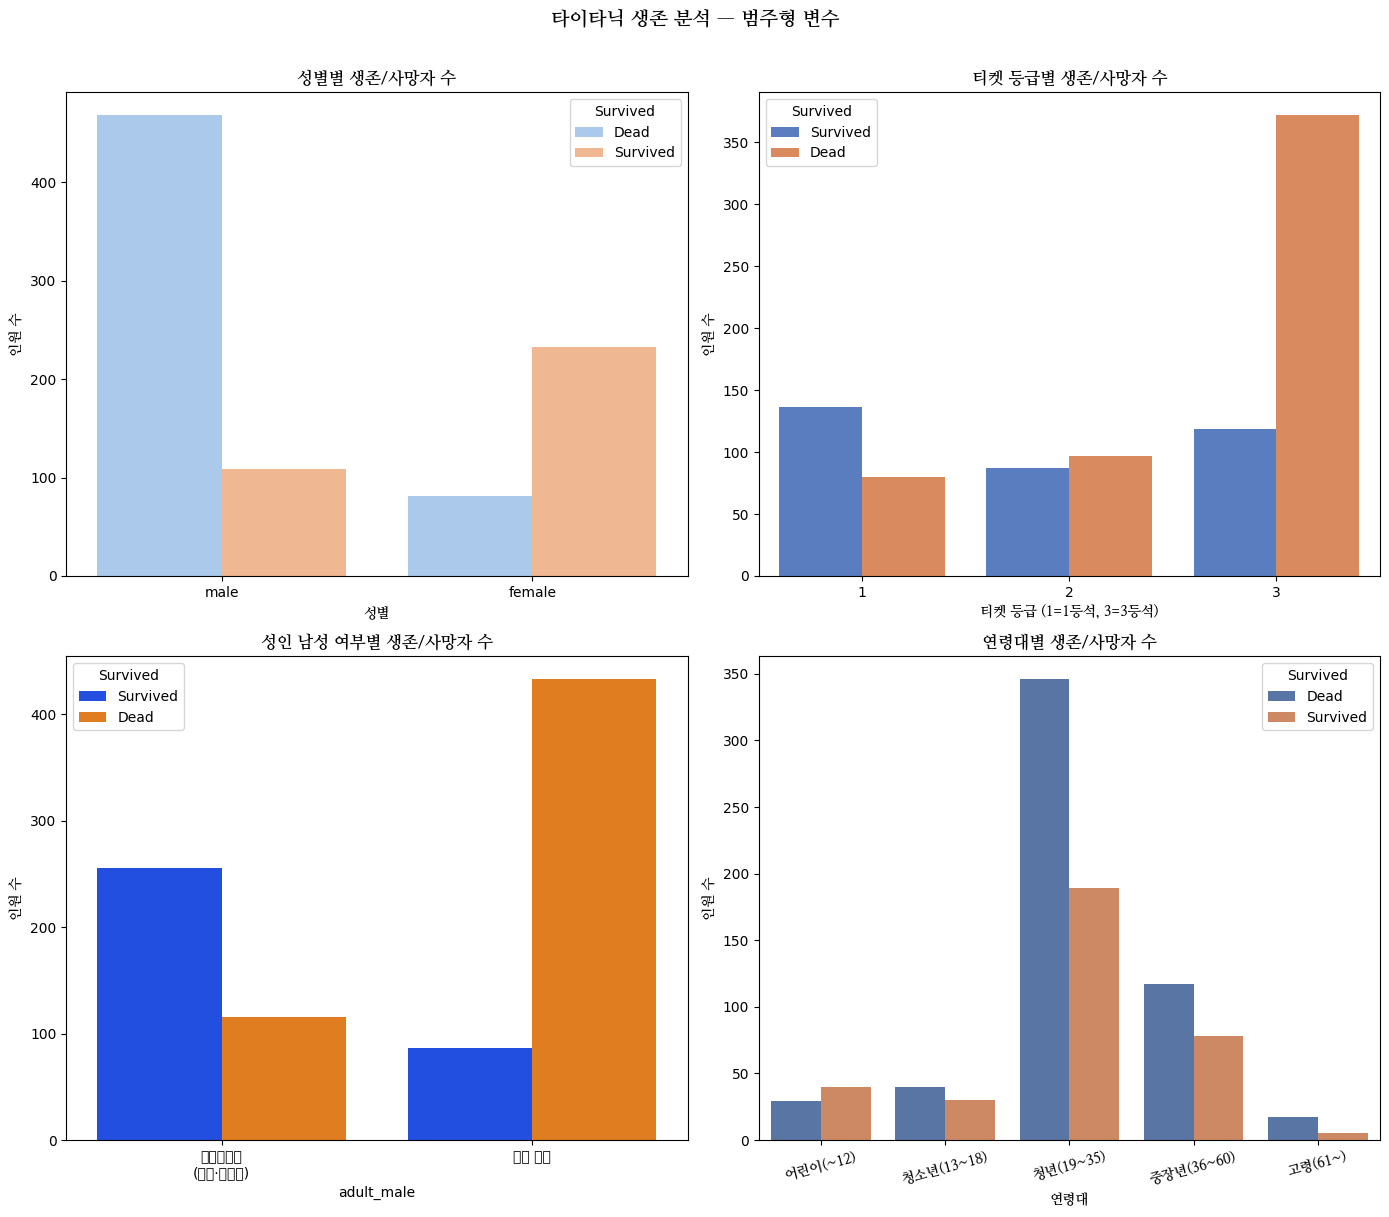

In [7]:
def title(ax, text):
    if font_prop:
        ax.set_title(text, fontproperties=font_prop, fontsize=12, fontweight='bold')
    else:
        ax.set_title(text, fontsize=12, fontweight='bold')

def label(ax, xlabel='', ylabel=''):
    if font_prop:
        if xlabel: ax.set_xlabel(xlabel, fontproperties=font_prop)
        if ylabel: ax.set_ylabel(ylabel, fontproperties=font_prop)
    else:
        if xlabel: ax.set_xlabel(xlabel)
        if ylabel: ax.set_ylabel(ylabel)

# ---- 그림 1: 범주형 변수별 생존/사망자 수 ----
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1-1. 성별
sns.countplot(x='Sex', hue='Survived', data=data, ax=axes[0, 0], palette='pastel')
title(axes[0, 0], '성별별 생존/사망자 수')
label(axes[0, 0], '성별', '인원 수')

# 1-2. 클래스
sns.countplot(x='Pclass', hue='Survived', data=data, ax=axes[0, 1], palette='muted')
title(axes[0, 1], '티켓 등급별 생존/사망자 수')
label(axes[0, 1], '티켓 등급 (1=1등석, 3=3등석)', '인원 수')

# 1-3. 성인 남성 여부
sns.countplot(x='adult_male', hue='Survived', data=data, ax=axes[1, 0], palette='bright')
title(axes[1, 0], '성인 남성 여부별 생존/사망자 수')
axes[1, 0].set_xticklabels(['비성인남성\n(여성·미성년)', '성인 남성'])
label(axes[1, 0], '', '인원 수')

# 1-4. 연령대
age_order = ['어린이(~12)', '청소년(13~18)', '청년(19~35)', '중장년(36~60)', '고령(61~)']
sns.countplot(x='AgeGroup', hue='Survived', data=data, order=age_order, ax=axes[1, 1], palette='deep')
title(axes[1, 1], '연령대별 생존/사망자 수')
label(axes[1, 1], '연령대', '인원 수')
if font_prop:
    axes[1, 1].set_xticklabels(age_order, fontproperties=font_prop, rotation=15)

plt.suptitle('타이타닉 생존 분석 — 범주형 변수', fontsize=14, fontweight='bold',
             fontproperties=font_prop if font_prop else None, y=1.01)
plt.tight_layout()
plt.show()

/tmp/ipykernel_3962/3197927654.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  fs_rate = data.groupby('FamilySize').apply(
/tmp/ipykernel_3962/3197927654.py:35: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3962/3197927654.py:35: UserWarning: Glyph 52404 (\N{HANGUL SYLLABLE CE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3962/3197927654.py:35: UserWarning: Glyph 49373 (\N{HANGUL SYLLABLE SAENG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3962/3197927654.py:35: UserWarning: Glyph 51316 (\N{HANGUL SYLLABLE JON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()

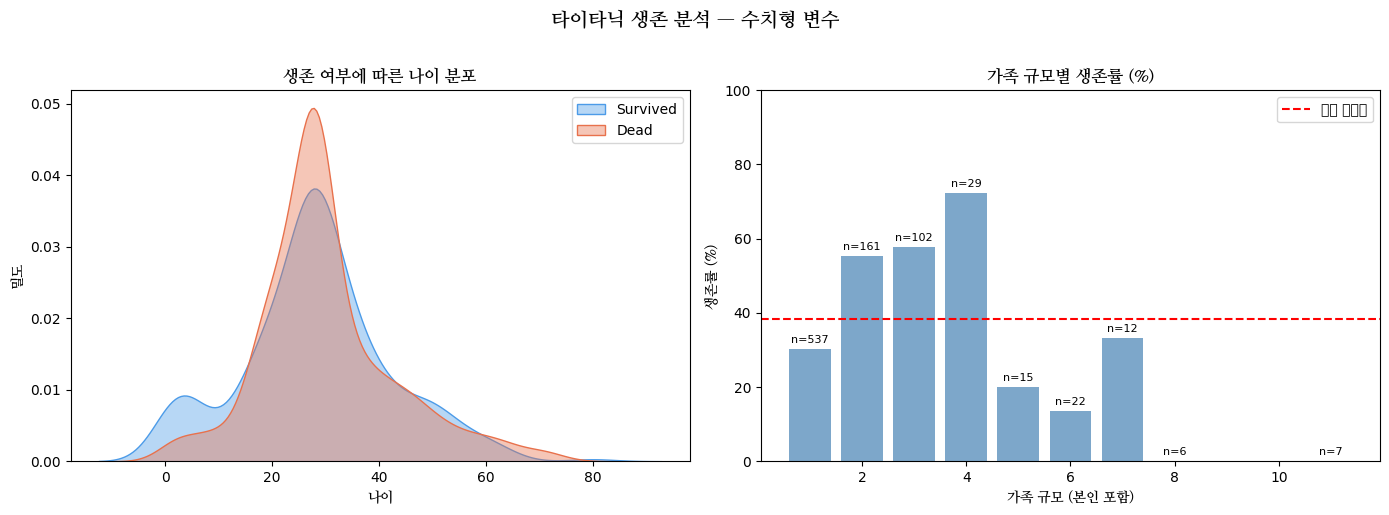

In [8]:
# ---- 그림 2: 수치형 변수 분포 ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 2-1. 나이 분포
for label_val, color in [('Survived', '#4C9BE8'), ('Dead', '#E8714C')]:
    subset = data[data['Survived'] == label_val]['Age']
    sns.kdeplot(data=subset, label=label_val, fill=True, alpha=0.4, ax=axes[0], color=color)
title(axes[0], '생존 여부에 따른 나이 분포')
label(axes[0], '나이', '밀도')
axes[0].legend()

# 2-2. 가족 규모별 생존률
fs_rate = data.groupby('FamilySize').apply(
    lambda x: (x['Survived'] == 'Survived').mean() * 100
).reset_index()
fs_rate.columns = ['FamilySize', 'SurvivalRate']
fs_count = data['FamilySize'].value_counts().reset_index()
fs_count.columns = ['FamilySize', 'Count']
fs_merged = fs_rate.merge(fs_count, on='FamilySize').sort_values('FamilySize')

bars = axes[1].bar(fs_merged['FamilySize'], fs_merged['SurvivalRate'],
                   color='steelblue', alpha=0.7)
for bar, count in zip(bars, fs_merged['Count']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'n={count}', ha='center', va='bottom', fontsize=8)
axes[1].axhline(y=data[data['Survived']=='Survived'].shape[0]/len(data)*100,
                color='red', linestyle='--', label='전체 생존률')
axes[1].legend()
title(axes[1], '가족 규모별 생존률 (%)')
label(axes[1], '가족 규모 (본인 포함)', '생존률 (%)')
axes[1].set_ylim(0, 100)

plt.suptitle('타이타닉 생존 분석 — 수치형 변수', fontsize=14, fontweight='bold',
             fontproperties=font_prop if font_prop else None, y=1.02)
plt.tight_layout()
plt.show()

/tmp/ipykernel_3962/1849816771.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  deck_rate = data.groupby('Deck').apply(
/tmp/ipykernel_3962/1849816771.py:26: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3962/1849816771.py:26: UserWarning: Glyph 52404 (\N{HANGUL SYLLABLE CE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3962/1849816771.py:26: UserWarning: Glyph 49373 (\N{HANGUL SYLLABLE SAENG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3962/1849816771.py:26: UserWarning: Glyph 51316 (\N{HANGUL SYLLABLE JON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp

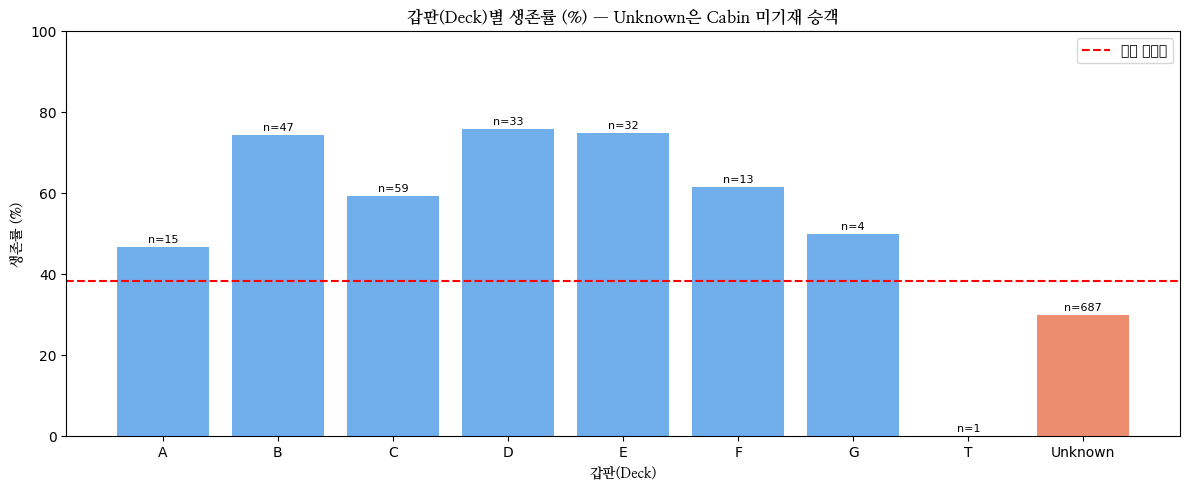

In [9]:
# ---- 그림 3: 갑판(Deck)별 생존률 ----
fig, ax = plt.subplots(figsize=(12, 5))

deck_rate = data.groupby('Deck').apply(
    lambda x: (x['Survived'] == 'Survived').mean() * 100
).reset_index()
deck_rate.columns = ['Deck', 'SurvivalRate']
deck_count = data['Deck'].value_counts().reset_index()
deck_count.columns = ['Deck', 'Count']
deck_merged = deck_rate.merge(deck_count, on='Deck')
deck_order_plot = sorted([d for d in deck_merged['Deck'] if d != 'Unknown']) + ['Unknown']
deck_merged = deck_merged.set_index('Deck').loc[deck_order_plot].reset_index()

colors = ['#E8714C' if d == 'Unknown' else '#4C9BE8' for d in deck_merged['Deck']]
bars = ax.bar(deck_merged['Deck'], deck_merged['SurvivalRate'], color=colors, alpha=0.8)
for bar, count in zip(bars, deck_merged['Count']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'n={count}', ha='center', va='bottom', fontsize=8)
ax.axhline(y=data[data['Survived']=='Survived'].shape[0]/len(data)*100,
           color='red', linestyle='--', label='전체 생존률')
ax.legend()
title(ax, '갑판(Deck)별 생존률 (%) — Unknown은 Cabin 미기재 승객')
label(ax, '갑판(Deck)', '생존률 (%)')
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

### 7. 분석 결과 요약: 누가 살아남고, 누가 사망했는가?

분석된 데이터와 역사적 사실을 종합해 볼 때, 타이타닉호에서의 생존과 사망은 다음과 같은 뚜렷한 경향을 보입니다.

> **데이터 전처리 참고**: 원본 1309명 전원을 분석에 포함했습니다. Age(263건)는 중앙값, Embarked(2건)는 최빈값으로 대체했으며, Cabin 미기재 승객(1014건, 약 77%)은 'Unknown' 갑판으로 처리해 분석 편향을 방지했습니다.

#### 1. 가장 높은 생존율을 보인 집단

- **여성과 어린이**: '여성과 아이 먼저' 원칙이 철저히 적용되었습니다. 비성인남성(여성·미성년) 그룹의 생존율은 압도적으로 높았습니다.
- **상류층(1, 2등석)**: 1등석과 2등석 승객의 생존율이 3등석보다 높았습니다. 갑판(구명보트)과 더 가까운 객실 위치 및 우선적 탑승권이 작용한 것으로 보입니다.
- **소규모 가족 동반 탑승자**: 가족 규모 2~4명 구간에서 생존율이 상대적으로 높게 나타났으며, 혼자 탑승한 경우보다 소규모 동반 탑승이 유리했습니다.

#### 2. 가장 높은 사망률을 보인 집단

- **성인 남성**: 성인 남성은 생존율이 가장 낮았으며, 구명보트 탑승 순위에서 밀려난 것이 주요 원인으로 분석됩니다.
- **하류층(3등석)**: 3등석 승객은 복잡한 선실 구조와 하부 데크 위치로 인해 탈출이 어려웠습니다.
- **대가족(가족 규모 5명 이상)**: 오히려 대가족은 혼자보다 생존율이 낮은 경향을 보였는데, 이는 가족 구성원을 찾느라 이동이 지체되었을 가능성을 시사합니다.
- **Cabin 미기재 승객(Unknown)**: Cabin 정보가 없는 승객 대부분은 3등석 이하로 추정되며, 생존율이 전체 평균보다 낮게 나타났습니다.

**결론**: '1·2등석에 탑승한 소규모 가족 동반 여성'이 가장 높은 생존 확률을 가졌으며, '3등석에 탑승한 성인 남성 단독 탑승자'가 가장 위험한 상황에 처해 있었다고 볼 수 있습니다.